In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled. Change the Colab runtime to T4 GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q thop

In [3]:
import os
import gc
import json
import time
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100
from torchvision.models import resnet18, ResNet18_Weights

from thop import profile

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cuda
GPU: Tesla T4


In [5]:
IMAGE_SIZE = 32
NUM_CLASSES = 100

BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

TRAIN_SIZE = 45000
VAL_SIZE = 5000

NUM_WORKERS = 2

print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)

Batch size: 64
Epochs: 10
Learning rate: 0.001


In [6]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [7]:
data_directory = "/content/data"

# Separate dataset objects allow training augmentation to be applied
# only to training images.
training_dataset_augmented = CIFAR100(
    root=data_directory,
    train=True,
    transform=train_transform,
    download=True
)

training_dataset_evaluation = CIFAR100(
    root=data_directory,
    train=True,
    transform=evaluation_transform,
    download=True
)

test_dataset = CIFAR100(
    root=data_directory,
    train=False,
    transform=evaluation_transform,
    download=True
)

# Create a reproducible train/validation split.
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(
    len(training_dataset_augmented),
    generator=generator
).tolist()

train_indices = indices[:TRAIN_SIZE]
val_indices = indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

train_dataset = Subset(
    training_dataset_augmented,
    train_indices
)

validation_dataset = Subset(
    training_dataset_evaluation,
    val_indices
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))
print("Number of classes:", len(test_dataset.classes))

Training images: 45000
Validation images: 5000
Test images: 10000
Number of classes: 100


In [9]:
loader_settings = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda"
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_settings
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_settings
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_settings
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum label:", labels.min().item())
print("Maximum label:", labels.max().item())

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Minimum label: 2
Maximum label: 98


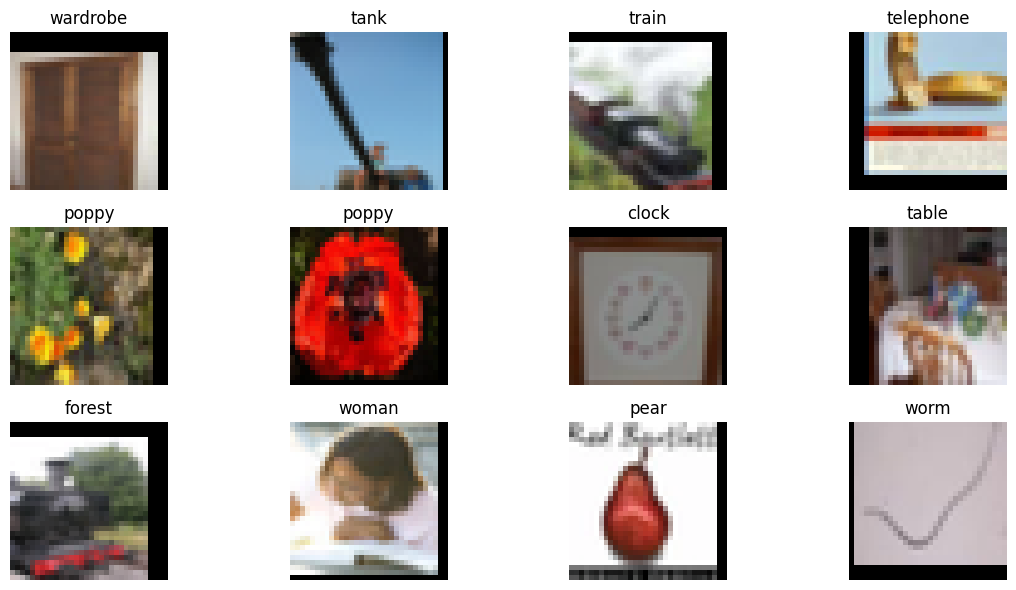

In [10]:
def unnormalize_image(image):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image.cpu() * std_tensor + mean_tensor
    return torch.clamp(image, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for index in range(12):
    plt.subplot(3, 4, index + 1)

    image = unnormalize_image(images[index])
    image = image.permute(1, 2, 0)

    plt.imshow(image)
    plt.title(test_dataset.classes[labels[index].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        input_channels=3,
        embedding_dimension=256
    ):
        super().__init__()

        if image_size % patch_size != 0:
            raise ValueError(
                "The image size must be divisible by the patch size."
            )

        self.image_size = image_size
        self.patch_size = patch_size

        self.patches_per_side = image_size // patch_size
        self.number_of_patches = self.patches_per_side ** 2

        self.projection = nn.Conv2d(
            in_channels=input_channels,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, images):
        # Input: [batch, channels, height, width]
        patches = self.projection(images)

        # [batch, embedding_dimension, patches_y, patches_x]
        patches = patches.flatten(2)

        # [batch, number_of_patches, embedding_dimension]
        patches = patches.transpose(1, 2)

        return patches

In [12]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        number_of_heads,
        attention_dropout=0.1,
        projection_dropout=0.1
    ):
        super().__init__()

        if embedding_dimension % number_of_heads != 0:
            raise ValueError(
                "Embedding dimension must be divisible by "
                "the number of attention heads."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_heads = number_of_heads
        self.head_dimension = (
            embedding_dimension // number_of_heads
        )

        self.scale = self.head_dimension ** -0.5

        # Compute query, key, and value in one linear operation.
        self.qkv = nn.Linear(
            embedding_dimension,
            embedding_dimension * 3
        )

        self.attention_dropout = nn.Dropout(attention_dropout)

        self.projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.projection_dropout = nn.Dropout(
            projection_dropout
        )

    def forward(self, x):
        batch_size, sequence_length, embedding_dimension = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            batch_size,
            sequence_length,
            3,
            self.number_of_heads,
            self.head_dimension
        )

        # [3, batch, heads, sequence, head_dimension]
        qkv = qkv.permute(2, 0, 3, 1, 4)

        query, key, value = qkv[0], qkv[1], qkv[2]

        attention_scores = (
            query @ key.transpose(-2, -1)
        ) * self.scale

        attention_weights = attention_scores.softmax(dim=-1)
        attention_weights = self.attention_dropout(
            attention_weights
        )

        output = attention_weights @ value

        output = output.transpose(1, 2).reshape(
            batch_size,
            sequence_length,
            embedding_dimension
        )

        output = self.projection(output)
        output = self.projection_dropout(output)

        return output

In [13]:
class TransformerMLP(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        hidden_dimension = int(
            embedding_dimension * mlp_ratio
        )

        self.layers = nn.Sequential(
            nn.Linear(
                embedding_dimension,
                hidden_dimension
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dimension,
                embedding_dimension
            ),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        number_of_heads,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        self.normalization_1 = nn.LayerNorm(
            embedding_dimension
        )

        self.attention = MultiHeadSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_heads=number_of_heads,
            attention_dropout=dropout,
            projection_dropout=dropout
        )

        self.normalization_2 = nn.LayerNorm(
            embedding_dimension
        )

        self.mlp = TransformerMLP(
            embedding_dimension=embedding_dimension,
            mlp_ratio=mlp_ratio,
            dropout=dropout
        )

    def forward(self, x):
        # Attention residual connection
        x = x + self.attention(
            self.normalization_1(x)
        )

        # MLP residual connection
        x = x + self.mlp(
            self.normalization_2(x)
        )

        return x

In [15]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        input_channels=3,
        number_of_classes=100,
        embedding_dimension=256,
        number_of_blocks=4,
        number_of_heads=4,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size
        self.embedding_dimension = embedding_dimension
        self.number_of_blocks = number_of_blocks
        self.number_of_heads = number_of_heads
        self.mlp_ratio = mlp_ratio

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            input_channels=input_channels,
            embedding_dimension=embedding_dimension
        )

        number_of_patches = (
            self.patch_embedding.number_of_patches
        )

        # One class token per model.
        self.class_token = nn.Parameter(
            torch.zeros(1, 1, embedding_dimension)
        )

        # Positional embedding includes one position
        # for the class token.
        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                number_of_patches + 1,
                embedding_dimension
            )
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embedding_dimension=embedding_dimension,
                number_of_heads=number_of_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout
            )
            for _ in range(number_of_blocks)
        ])

        self.final_normalization = nn.LayerNorm(
            embedding_dimension
        )

        self.classification_head = nn.Linear(
            embedding_dimension,
            number_of_classes
        )

        self.initialize_parameters()

    def initialize_parameters(self):
        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.class_token,
            std=0.02
        )

        nn.init.trunc_normal_(
            self.patch_embedding.projection.weight,
            std=0.02
        )

        if self.patch_embedding.projection.bias is not None:
            nn.init.zeros_(
                self.patch_embedding.projection.bias
            )

        nn.init.trunc_normal_(
            self.classification_head.weight,
            std=0.02
        )

        nn.init.zeros_(
            self.classification_head.bias
        )

    def forward(self, images):
        batch_size = images.shape[0]

        x = self.patch_embedding(images)

        class_tokens = self.class_token.expand(
            batch_size,
            -1,
            -1
        )

        x = torch.cat(
            [class_tokens, x],
            dim=1
        )

        x = x + self.position_embedding
        x = self.embedding_dropout(x)

        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)

        x = self.final_normalization(x)

        # Use the class-token representation.
        class_representation = x[:, 0]

        logits = self.classification_head(
            class_representation
        )

        return logits

In [16]:
test_vit = VisionTransformer(
    image_size=32,
    patch_size=4,
    number_of_classes=100,
    embedding_dimension=256,
    number_of_blocks=4,
    number_of_heads=4,
    mlp_ratio=4,
    dropout=0.1
).to(device)

dummy_images = torch.randn(
    2,
    3,
    32,
    32
).to(device)

with torch.no_grad():
    dummy_output = test_vit(dummy_images)

print("Input shape:", dummy_images.shape)
print("Output shape:", dummy_output.shape)

del test_vit
del dummy_images
del dummy_output

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 100])


In [17]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def count_all_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def calculate_theoretical_vit_parameters(
    image_size,
    patch_size,
    embedding_dimension,
    number_of_blocks,
    number_of_heads,
    number_of_classes=100,
    input_channels=3,
    mlp_ratio=4
):
    if embedding_dimension % number_of_heads != 0:
        raise ValueError(
            "Embedding dimension must be divisible by heads."
        )

    number_of_patches = (
        image_size // patch_size
    ) ** 2

    sequence_length = number_of_patches + 1

    # Convolutional patch projection: weights + bias
    patch_embedding_parameters = (
        embedding_dimension
        * input_channels
        * patch_size
        * patch_size
        + embedding_dimension
    )

    class_token_parameters = embedding_dimension

    positional_parameters = (
        sequence_length * embedding_dimension
    )

    # QKV projection and output projection
    attention_parameters_per_block = (
        3 * embedding_dimension * embedding_dimension
        + 3 * embedding_dimension
        + embedding_dimension * embedding_dimension
        + embedding_dimension
    )

    hidden_dimension = int(
        mlp_ratio * embedding_dimension
    )

    mlp_parameters_per_block = (
        embedding_dimension * hidden_dimension
        + hidden_dimension
        + hidden_dimension * embedding_dimension
        + embedding_dimension
    )

    # Two LayerNorm layers in each block
    normalization_parameters_per_block = (
        4 * embedding_dimension
    )

    parameters_per_block = (
        attention_parameters_per_block
        + mlp_parameters_per_block
        + normalization_parameters_per_block
    )

    transformer_parameters = (
        number_of_blocks * parameters_per_block
    )

    # Final LayerNorm
    final_normalization_parameters = (
        2 * embedding_dimension
    )

    classification_parameters = (
        embedding_dimension * number_of_classes
        + number_of_classes
    )

    total_parameters = (
        patch_embedding_parameters
        + class_token_parameters
        + positional_parameters
        + transformer_parameters
        + final_normalization_parameters
        + classification_parameters
    )

    return total_parameters

In [18]:
def calculate_approximate_vit_flops(
    image_size,
    patch_size,
    embedding_dimension,
    number_of_blocks,
    number_of_classes=100,
    input_channels=3,
    mlp_ratio=4
):
    number_of_patches = (
        image_size // patch_size
    ) ** 2

    sequence_length = number_of_patches + 1

    # Patch projection convolution
    patch_embedding_flops = (
        2
        * number_of_patches
        * input_channels
        * patch_size
        * patch_size
        * embedding_dimension
    )

    # QKV projections and output projection
    attention_projection_flops = (
        8
        * sequence_length
        * embedding_dimension
        * embedding_dimension
    )

    # QK^T and attention-weighted V
    attention_matrix_flops = (
        4
        * sequence_length
        * sequence_length
        * embedding_dimension
    )

    # Two MLP linear layers
    mlp_flops = (
        4
        * mlp_ratio
        * sequence_length
        * embedding_dimension
        * embedding_dimension
    )

    block_flops = (
        attention_projection_flops
        + attention_matrix_flops
        + mlp_flops
    )

    classification_flops = (
        2
        * embedding_dimension
        * number_of_classes
    )

    total_flops = (
        patch_embedding_flops
        + number_of_blocks * block_flops
        + classification_flops
    )

    return total_flops

In [19]:
verification_model = VisionTransformer(
    image_size=32,
    patch_size=4,
    number_of_classes=100,
    embedding_dimension=256,
    number_of_blocks=4,
    number_of_heads=4,
    mlp_ratio=4,
    dropout=0.1
)

actual_parameters = count_all_parameters(
    verification_model
)

theoretical_parameters = (
    calculate_theoretical_vit_parameters(
        image_size=32,
        patch_size=4,
        embedding_dimension=256,
        number_of_blocks=4,
        number_of_heads=4,
        number_of_classes=100,
        mlp_ratio=4
    )
)

approximate_flops = calculate_approximate_vit_flops(
    image_size=32,
    patch_size=4,
    embedding_dimension=256,
    number_of_blocks=4,
    number_of_classes=100,
    mlp_ratio=4
)

print(f"Actual parameters:      {actual_parameters:,}")
print(f"Theoretical parameters: {theoretical_parameters:,}")
print(f"Approximate FLOPs:       {approximate_flops:,}")
print(f"Approximate GFLOPs:      {approximate_flops / 1e9:.4f}")

assert actual_parameters == theoretical_parameters

del verification_model

Actual parameters:      3,214,692
Theoretical parameters: 3,214,692
Approximate FLOPs:       427,874,304
Approximate GFLOPs:      0.4279


In [20]:
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        predictions = model(images)
        loss = loss_function(predictions, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            predictions.argmax(dim=1) == labels
        ).sum().item()

        total_examples += batch_size

    average_loss = total_loss / total_examples
    accuracy = 100.0 * total_correct / total_examples

    return average_loss, accuracy

In [21]:
@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        predictions = model(images)
        loss = loss_function(predictions, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (
            predictions.argmax(dim=1) == labels
        ).sum().item()

        total_examples += batch_size

    average_loss = total_loss / total_examples
    accuracy = 100.0 * total_correct / total_examples

    return average_loss, accuracy

In [22]:
def train_complete_model(
    model,
    model_name,
    train_loader,
    validation_loader,
    test_loader,
    number_of_epochs=10,
    learning_rate=0.001
):
    model = model.to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "epoch_time_seconds": []
    }

    best_validation_accuracy = 0.0
    best_model_state = None

    print("=" * 75)
    print("Training:", model_name)
    print("=" * 75)

    for epoch in range(number_of_epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        train_loss, train_accuracy = train_one_epoch(
            model=model,
            data_loader=train_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            device=device
        )

        validation_loss, validation_accuracy = evaluate_model(
            model=model,
            data_loader=validation_loader,
            loss_function=loss_function,
            device=device
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        epoch_time = time.perf_counter() - start_time

        history["train_loss"].append(
            float(train_loss)
        )

        history["train_accuracy"].append(
            float(train_accuracy)
        )

        history["validation_loss"].append(
            float(validation_loss)
        )

        history["validation_accuracy"].append(
            float(validation_accuracy)
        )

        history["epoch_time_seconds"].append(
            float(epoch_time)
        )

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch + 1:02d}/{number_of_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.2f}% | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation accuracy: {validation_accuracy:.2f}% | "
            f"Time: {epoch_time:.2f} seconds"
        )

    # Use the best validation checkpoint for final test evaluation.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_loss, test_accuracy = evaluate_model(
        model=model,
        data_loader=test_loader,
        loss_function=loss_function,
        device=device
    )

    average_epoch_time = np.mean(
        history["epoch_time_seconds"]
    )

    total_training_time = np.sum(
        history["epoch_time_seconds"]
    )

    checkpoint_path = (
        f"/content/{model_name}_best.pth"
    )

    torch.save(
        model.state_dict(),
        checkpoint_path
    )

    print("-" * 75)
    print(f"Best validation accuracy: {best_validation_accuracy:.2f}%")
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.2f}%")
    print(f"Average time per epoch: {average_epoch_time:.2f} seconds")
    print(f"Total training time: {total_training_time:.2f} seconds")
    print("Saved checkpoint:", checkpoint_path)

    final_metrics = {
        "best_validation_accuracy": float(
            best_validation_accuracy
        ),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "average_epoch_time_seconds": float(
            average_epoch_time
        ),
        "total_training_time_seconds": float(
            total_training_time
        )
    }

    return model, history, final_metrics

In [23]:
vit_configurations = {
    "ViT_A_P4_D256_L4_H4": {
        "patch_size": 4,
        "embedding_dimension": 256,
        "number_of_blocks": 4,
        "number_of_heads": 4
    },

    "ViT_B_P8_D256_L4_H4": {
        "patch_size": 8,
        "embedding_dimension": 256,
        "number_of_blocks": 4,
        "number_of_heads": 4
    },

    "ViT_C_P4_D512_L4_H8": {
        "patch_size": 4,
        "embedding_dimension": 512,
        "number_of_blocks": 4,
        "number_of_heads": 8
    },

    "ViT_D_P4_D256_L8_H8": {
        "patch_size": 4,
        "embedding_dimension": 256,
        "number_of_blocks": 8,
        "number_of_heads": 8
    }
}

configuration_table = pd.DataFrame.from_dict(
    vit_configurations,
    orient="index"
)

configuration_table.index.name = "Model"

configuration_table

,patch_size,embedding_dimension,number_of_blocks,number_of_heads
Model,,,,
ViT_A_P4_D256_L4_H4,4,256,4,4
ViT_B_P8_D256_L4_H4,8,256,4,4
ViT_C_P4_D512_L4_H8,4,512,4,8
ViT_D_P4_D256_L8_H8,4,256,8,8


In [24]:
complexity_rows = []

for model_name, configuration in vit_configurations.items():
    parameters = calculate_theoretical_vit_parameters(
        image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        embedding_dimension=configuration[
            "embedding_dimension"
        ],
        number_of_blocks=configuration[
            "number_of_blocks"
        ],
        number_of_heads=configuration[
            "number_of_heads"
        ],
        number_of_classes=NUM_CLASSES,
        mlp_ratio=4
    )

    flops = calculate_approximate_vit_flops(
        image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        embedding_dimension=configuration[
            "embedding_dimension"
        ],
        number_of_blocks=configuration[
            "number_of_blocks"
        ],
        number_of_classes=NUM_CLASSES,
        mlp_ratio=4
    )

    number_of_patches = (
        IMAGE_SIZE // configuration["patch_size"]
    ) ** 2

    complexity_rows.append({
        "Model": model_name,
        "Patch Size": configuration["patch_size"],
        "Number of Patches": number_of_patches,
        "Sequence Length": number_of_patches + 1,
        "Embedding Dimension": configuration[
            "embedding_dimension"
        ],
        "Blocks": configuration[
            "number_of_blocks"
        ],
        "Heads": configuration[
            "number_of_heads"
        ],
        "Parameters": parameters,
        "Parameters (Millions)": parameters / 1e6,
        "Approximate GFLOPs": flops / 1e9
    })

complexity_table = pd.DataFrame(complexity_rows)

complexity_table

,Model,Patch Size,Number of Patches,Sequence Length,Embedding Dimension,Blocks,Heads,Parameters,Parameters (Millions),Approximate GFLOPs
0,ViT_A_P4_D256_L4_H4,4,64,65,256,4,4,3214692,3.214692,0.427874
1,ViT_B_P8_D256_L4_H4,8,16,17,256,4,4,3239268,3.239268,0.109763
2,ViT_C_P4_D512_L4_H8,4,64,65,512,4,8,12720740,12.720740,1.673638
3,ViT_D_P4_D256_L8_H8,4,64,65,256,8,8,6373732,6.373732,0.854125


In [25]:
all_results = []
all_histories = {}

for model_name, configuration in vit_configurations.items():
    print("\n")
    print("#" * 80)
    print("Starting experiment:", model_name)
    print("#" * 80)

    model = VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=configuration["patch_size"],
        input_channels=3,
        number_of_classes=NUM_CLASSES,
        embedding_dimension=configuration[
            "embedding_dimension"
        ],
        number_of_blocks=configuration[
            "number_of_blocks"
        ],
        number_of_heads=configuration[
            "number_of_heads"
        ],
        mlp_ratio=4,
        dropout=0.1
    )

    actual_parameters = count_trainable_parameters(
        model
    )

    theoretical_parameters = (
        calculate_theoretical_vit_parameters(
            image_size=IMAGE_SIZE,
            patch_size=configuration["patch_size"],
            embedding_dimension=configuration[
                "embedding_dimension"
            ],
            number_of_blocks=configuration[
                "number_of_blocks"
            ],
            number_of_heads=configuration[
                "number_of_heads"
            ],
            number_of_classes=NUM_CLASSES,
            mlp_ratio=4
        )
    )

    approximate_flops = (
        calculate_approximate_vit_flops(
            image_size=IMAGE_SIZE,
            patch_size=configuration["patch_size"],
            embedding_dimension=configuration[
                "embedding_dimension"
            ],
            number_of_blocks=configuration[
                "number_of_blocks"
            ],
            number_of_classes=NUM_CLASSES,
            mlp_ratio=4
        )
    )

    if actual_parameters != theoretical_parameters:
        raise ValueError(
            f"Parameter-count mismatch for {model_name}: "
            f"actual={actual_parameters}, "
            f"theoretical={theoretical_parameters}"
        )

    trained_model, history, metrics = (
        train_complete_model(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            validation_loader=validation_loader,
            test_loader=test_loader,
            number_of_epochs=NUM_EPOCHS,
            learning_rate=LEARNING_RATE
        )
    )

    all_histories[model_name] = history

    all_results.append({
        "Model": model_name,
        "Model Type": "ViT from scratch",
        "Patch Size": configuration["patch_size"],
        "Embedding Dimension": configuration[
            "embedding_dimension"
        ],
        "Blocks": configuration[
            "number_of_blocks"
        ],
        "Heads": configuration[
            "number_of_heads"
        ],
        "Trainable Parameters": actual_parameters,
        "Parameters (Millions)": actual_parameters / 1e6,
        "Approximate GFLOPs": approximate_flops / 1e9,
        "Best Validation Accuracy (%)": metrics[
            "best_validation_accuracy"
        ],
        "Test Accuracy (%)": metrics[
            "test_accuracy"
        ],
        "Test Loss": metrics["test_loss"],
        "Average Time per Epoch (s)": metrics[
            "average_epoch_time_seconds"
        ],
        "Total Training Time (s)": metrics[
            "total_training_time_seconds"
        ]
    })

    del trained_model
    del model

    gc.collect()

    if device.type == "cuda":
        torch.cuda.empty_cache()

print("All four ViT experiments are complete.")



################################################################################
Starting experiment: ViT_A_P4_D256_L4_H4
################################################################################
Training: ViT_A_P4_D256_L4_H4
Epoch 01/10 | Train loss: 4.0672 | Train accuracy: 7.28% | Validation loss: 3.7792 | Validation accuracy: 11.26% | Time: 29.27 seconds
Epoch 02/10 | Train loss: 3.7327 | Train accuracy: 11.87% | Validation loss: 3.4880 | Validation accuracy: 16.32% | Time: 29.46 seconds
Epoch 03/10 | Train loss: 3.5597 | Train accuracy: 14.74% | Validation loss: 3.4332 | Validation accuracy: 17.20% | Time: 30.52 seconds
Epoch 04/10 | Train loss: 3.4538 | Train accuracy: 16.42% | Validation loss: 3.3545 | Validation accuracy: 18.78% | Time: 30.62 seconds
Epoch 05/10 | Train loss: 3.3799 | Train accuracy: 17.84% | Validation loss: 3.2426 | Validation accuracy: 21.12% | Time: 30.49 seconds
Epoch 06/10 | Train loss: 3.3199 | Train accuracy: 18.94% | Validation loss: 3.1726 | 

In [26]:
vit_results_dataframe = pd.DataFrame(
    all_results
)

vit_results_dataframe.to_csv(
    "/content/vit_results.csv",
    index=False
)

with open(
    "/content/vit_histories.json",
    "w"
) as file:
    json.dump(
        all_histories,
        file,
        indent=4
    )

vit_results_dataframe

,Model,Model Type,Patch Size,Embedding Dimension,Blocks,Heads,Trainable Parameters,Parameters (Millions),Approximate GFLOPs,Best Validation Accuracy (%),Test Accuracy (%),Test Loss,Average Time per Epoch (s),Total Training Time (s)
0,ViT_A_P4_D256_L4_H4,ViT from scratch,4,256,4,4,3214692,3.214692,0.427874,23.98,23.53,3.093775,30.203158,302.031581
1,ViT_B_P8_D256_L4_H4,ViT from scratch,8,256,4,4,3239268,3.239268,0.109763,10.24,10.23,3.859056,25.262315,252.623148
2,ViT_C_P4_D512_L4_H8,ViT from scratch,4,512,4,8,12720740,12.720740,1.673638,8.14,7.76,4.041581,84.221296,842.212964
3,ViT_D_P4_D256_L8_H8,ViT from scratch,4,256,8,8,6373732,6.373732,0.854125,29.36,28.36,2.839968,59.678080,596.780797


In [27]:
def build_pretrained_resnet18_for_cifar100():
    weights = ResNet18_Weights.DEFAULT

    model = resnet18(weights=weights)

    original_convolution_weights = (
        model.conv1.weight.detach().clone()
    )

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    # Transfer the center portion of the pretrained
    # 7x7 convolution to the new 3x3 convolution.
    with torch.no_grad():
        model.conv1.weight.copy_(
            original_convolution_weights[
                :,
                :,
                2:5,
                2:5
            ]
        )

    model.maxpool = nn.Identity()

    input_features = model.fc.in_features

    model.fc = nn.Linear(
        input_features,
        NUM_CLASSES
    )

    return model

In [28]:
resnet_model = (
    build_pretrained_resnet18_for_cifar100()
)

dummy_input = torch.randn(
    2,
    3,
    32,
    32
)

with torch.no_grad():
    dummy_output = resnet_model(dummy_input)

print("ResNet input shape:", dummy_input.shape)
print("ResNet output shape:", dummy_output.shape)
print(
    "Trainable parameters:",
    f"{count_trainable_parameters(resnet_model):,}"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


ResNet input shape: torch.Size([2, 3, 32, 32])
ResNet output shape: torch.Size([2, 100])
Trainable parameters: 11,220,132


In [29]:
resnet_model_for_complexity = (
    build_pretrained_resnet18_for_cifar100()
)

dummy_resnet_input = torch.randn(
    1,
    3,
    32,
    32
)

resnet_macs, resnet_parameter_estimate = profile(
    resnet_model_for_complexity,
    inputs=(dummy_resnet_input,),
    verbose=False
)

# Multiply-accumulate is reported as approximately
# two floating-point operations.
resnet_flops = 2 * resnet_macs

print(f"ResNet-18 MACs: {resnet_macs:,}")
print(f"Approximate FLOPs: {resnet_flops:,}")
print(f"Approximate GFLOPs: {resnet_flops / 1e9:.4f}")
print(
    "Exact trainable parameters:",
    f"{count_trainable_parameters(resnet_model_for_complexity):,}"
)

del resnet_model_for_complexity
del dummy_resnet_input
gc.collect()

ResNet-18 MACs: 557,935,104.0
Approximate FLOPs: 1,115,870,208.0
Approximate GFLOPs: 1.1159
Exact trainable parameters: 11,220,132


1665

In [30]:
resnet_model = (
    build_pretrained_resnet18_for_cifar100()
)

resnet_parameters = count_trainable_parameters(
    resnet_model
)

trained_resnet, resnet_history, resnet_metrics = (
    train_complete_model(
        model=resnet_model,
        model_name="Pretrained_ResNet18",
        train_loader=train_loader,
        validation_loader=validation_loader,
        test_loader=test_loader,
        number_of_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE
    )
)

all_histories["Pretrained_ResNet18"] = (
    resnet_history
)

all_results.append({
    "Model": "Pretrained_ResNet18",
    "Model Type": "Pretrained ResNet-18",
    "Patch Size": np.nan,
    "Embedding Dimension": np.nan,
    "Blocks": 8,
    "Heads": np.nan,
    "Trainable Parameters": resnet_parameters,
    "Parameters (Millions)": resnet_parameters / 1e6,
    "Approximate GFLOPs": resnet_flops / 1e9,
    "Best Validation Accuracy (%)": resnet_metrics[
        "best_validation_accuracy"
    ],
    "Test Accuracy (%)": resnet_metrics[
        "test_accuracy"
    ],
    "Test Loss": resnet_metrics["test_loss"],
    "Average Time per Epoch (s)": resnet_metrics[
        "average_epoch_time_seconds"
    ],
    "Total Training Time (s)": resnet_metrics[
        "total_training_time_seconds"
    ]
})

del trained_resnet
del resnet_model

gc.collect()

if device.type == "cuda":
    torch.cuda.empty_cache()

Training: Pretrained_ResNet18
Epoch 01/10 | Train loss: 2.3907 | Train accuracy: 37.50% | Validation loss: 1.9993 | Validation accuracy: 47.10% | Time: 41.90 seconds
Epoch 02/10 | Train loss: 1.5911 | Train accuracy: 54.97% | Validation loss: 1.5541 | Validation accuracy: 57.22% | Time: 40.72 seconds
Epoch 03/10 | Train loss: 1.3244 | Train accuracy: 61.91% | Validation loss: 1.3767 | Validation accuracy: 61.86% | Time: 41.98 seconds
Epoch 04/10 | Train loss: 1.1606 | Train accuracy: 65.99% | Validation loss: 1.3478 | Validation accuracy: 63.56% | Time: 40.71 seconds
Epoch 05/10 | Train loss: 1.0277 | Train accuracy: 69.53% | Validation loss: 1.2593 | Validation accuracy: 64.78% | Time: 40.73 seconds
Epoch 06/10 | Train loss: 0.9217 | Train accuracy: 72.20% | Validation loss: 1.1782 | Validation accuracy: 68.02% | Time: 40.85 seconds
Epoch 07/10 | Train loss: 0.8332 | Train accuracy: 74.74% | Validation loss: 1.2228 | Validation accuracy: 66.58% | Time: 40.72 seconds
Epoch 08/10 | Trai

In [31]:
results_dataframe = pd.DataFrame(
    all_results
)

results_dataframe = results_dataframe.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_dataframe.to_csv(
    "/content/problem1_final_results.csv",
    index=False
)

with open(
    "/content/problem1_all_histories.json",
    "w"
) as file:
    json.dump(
        all_histories,
        file,
        indent=4
    )

results_dataframe

,Model,Model Type,Patch Size,Embedding Dimension,Blocks,Heads,Trainable Parameters,Parameters (Millions),Approximate GFLOPs,Best Validation Accuracy (%),Test Accuracy (%),Test Loss,Average Time per Epoch (s),Total Training Time (s)
0,Pretrained_ResNet18,Pretrained ResNet-18,NaN,NaN,8,NaN,11220132,11.220132,1.115870,69.64,68.79,1.255189,41.082781,410.827807
1,ViT_D_P4_D256_L8_H8,ViT from scratch,4.0,256.0,8,8.0,6373732,6.373732,0.854125,29.36,28.36,2.839968,59.678080,596.780797
2,ViT_A_P4_D256_L4_H4,ViT from scratch,4.0,256.0,4,4.0,3214692,3.214692,0.427874,23.98,23.53,3.093775,30.203158,302.031581
3,ViT_B_P8_D256_L4_H4,ViT from scratch,8.0,256.0,4,4.0,3239268,3.239268,0.109763,10.24,10.23,3.859056,25.262315,252.623148
4,ViT_C_P4_D512_L4_H8,ViT from scratch,4.0,512.0,4,8.0,12720740,12.720740,1.673638,8.14,7.76,4.041581,84.221296,842.212964


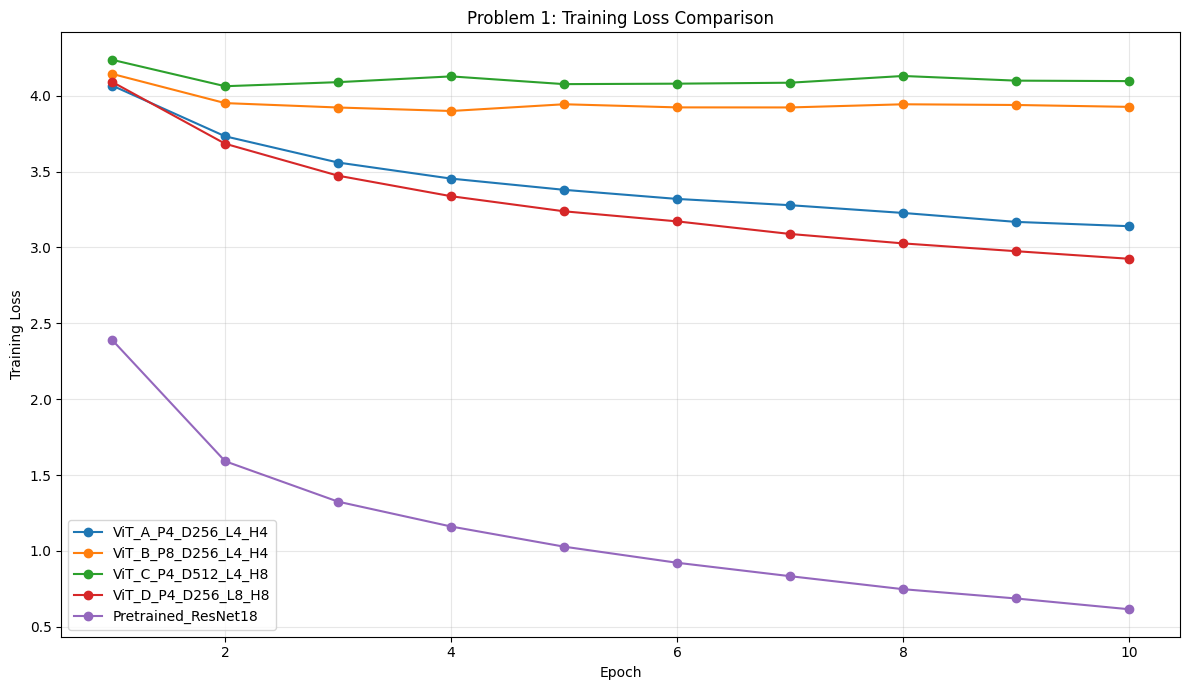

In [32]:
plt.figure(figsize=(12, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem 1: Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

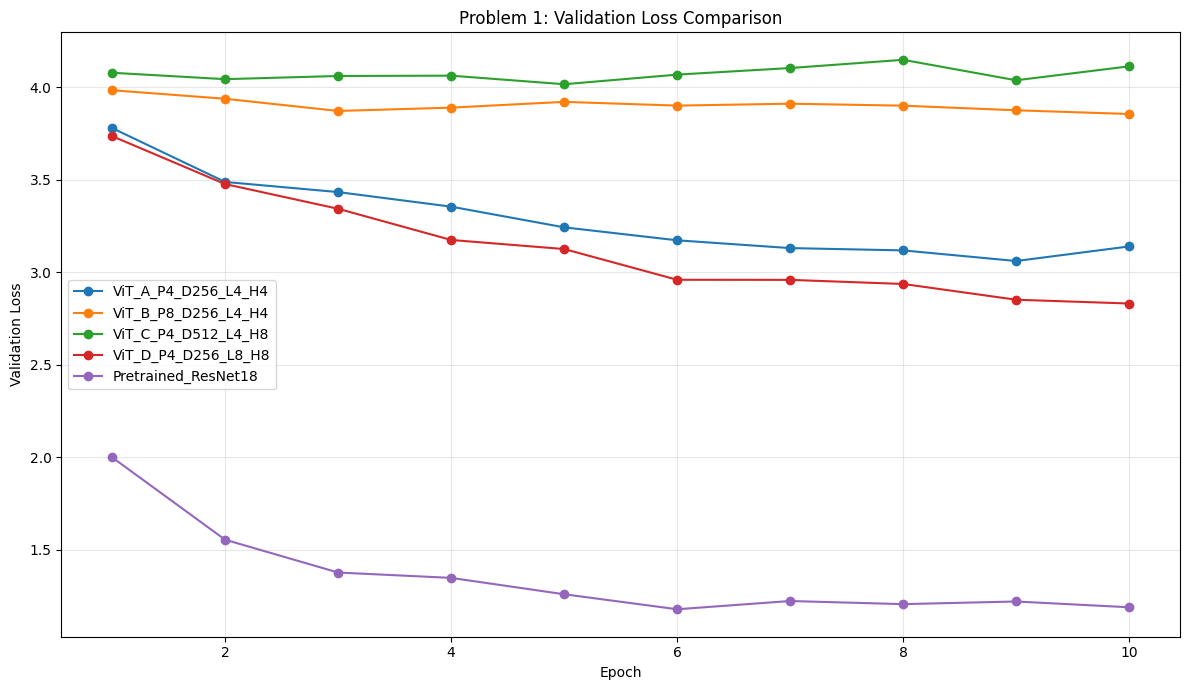

In [33]:
plt.figure(figsize=(12, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Problem 1: Validation Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

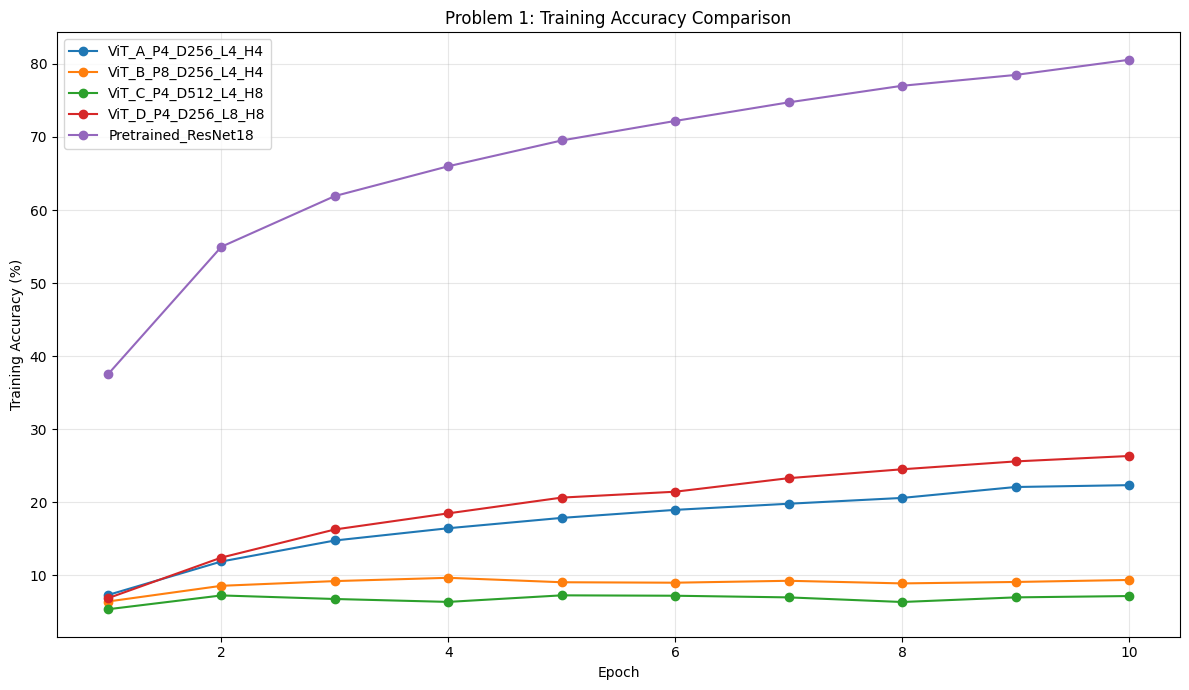

In [34]:
plt.figure(figsize=(12, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["train_accuracy"]) + 1
    )

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Problem 1: Training Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

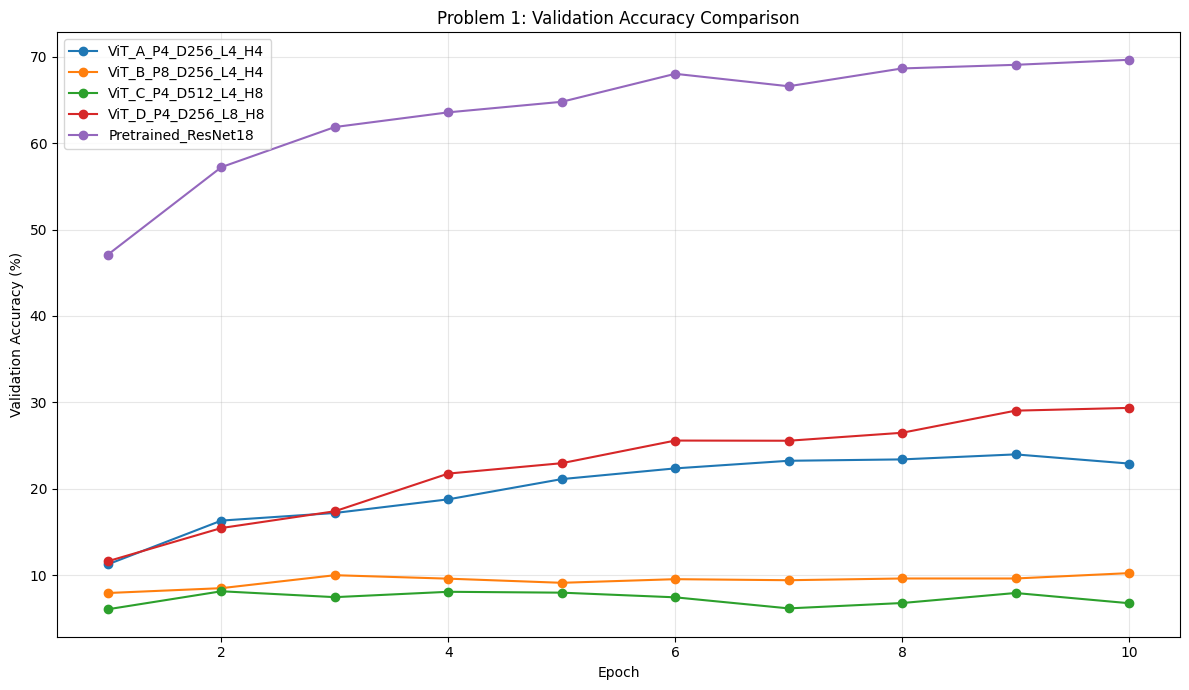

In [35]:
plt.figure(figsize=(12, 7))

for model_name, history in all_histories.items():
    epochs = range(
        1,
        len(history["validation_accuracy"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Problem 1: Validation Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

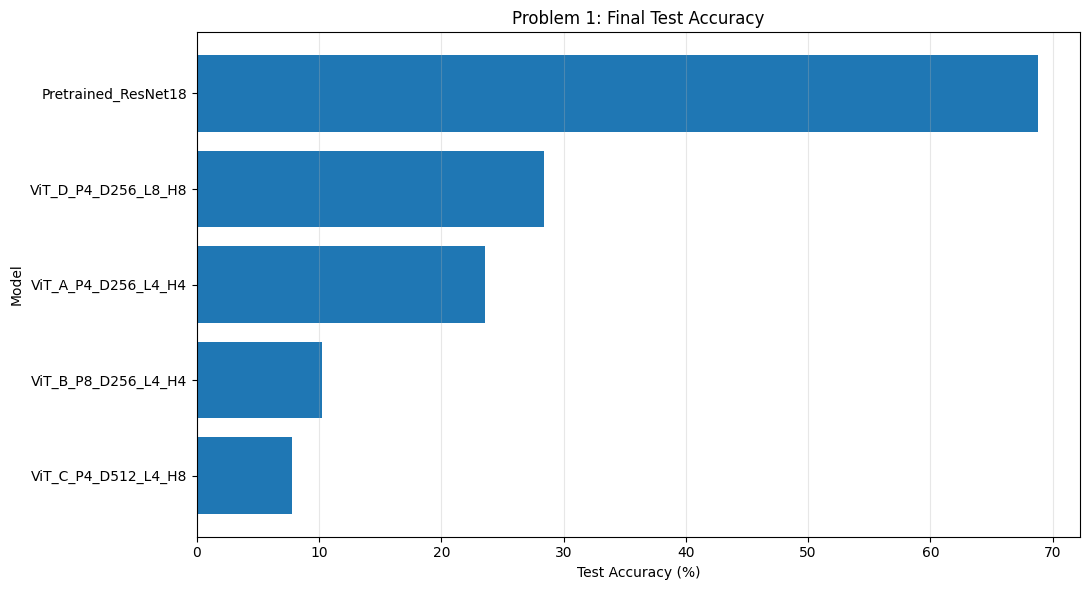

In [36]:
accuracy_plot_data = results_dataframe.sort_values(
    by="Test Accuracy (%)",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    accuracy_plot_data["Model"],
    accuracy_plot_data["Test Accuracy (%)"]
)

plt.xlabel("Test Accuracy (%)")
plt.ylabel("Model")
plt.title("Problem 1: Final Test Accuracy")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_test_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

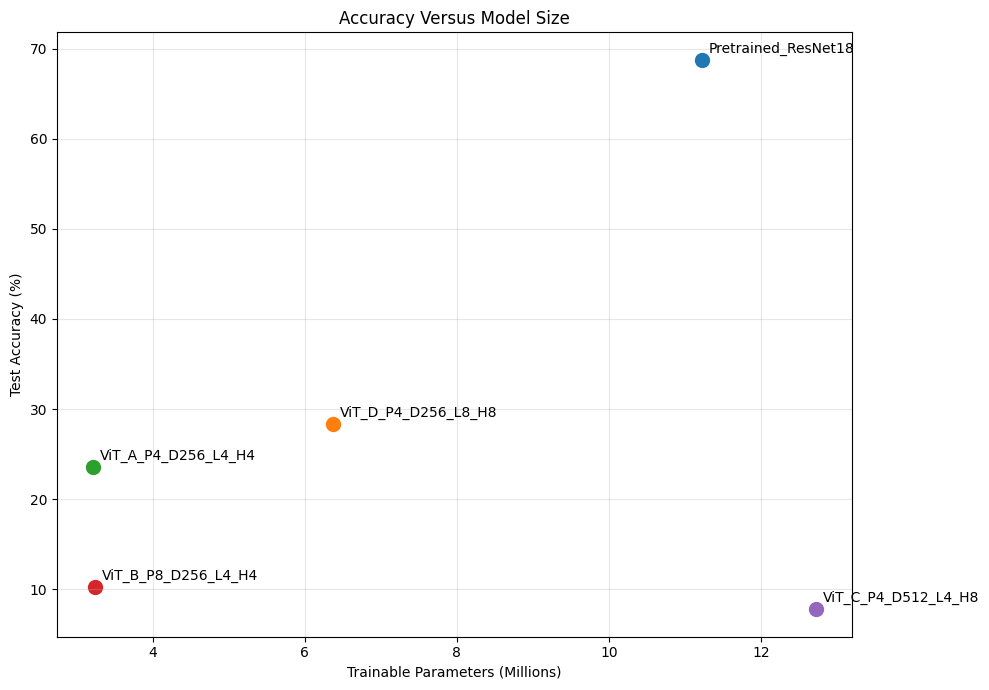

In [37]:
plt.figure(figsize=(10, 7))

for _, row in results_dataframe.iterrows():
    plt.scatter(
        row["Parameters (Millions)"],
        row["Test Accuracy (%)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["Parameters (Millions)"],
            row["Test Accuracy (%)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Trainable Parameters (Millions)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Versus Model Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_accuracy_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

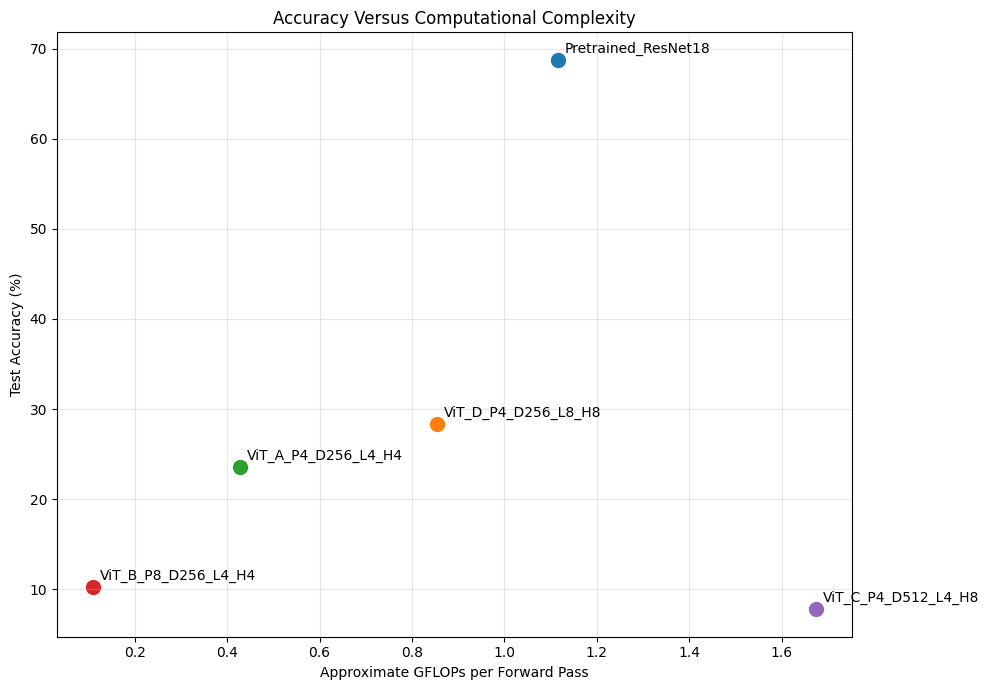

In [38]:
plt.figure(figsize=(10, 7))

for _, row in results_dataframe.iterrows():
    plt.scatter(
        row["Approximate GFLOPs"],
        row["Test Accuracy (%)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["Approximate GFLOPs"],
            row["Test Accuracy (%)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Approximate GFLOPs per Forward Pass")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Versus Computational Complexity")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_accuracy_vs_flops.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

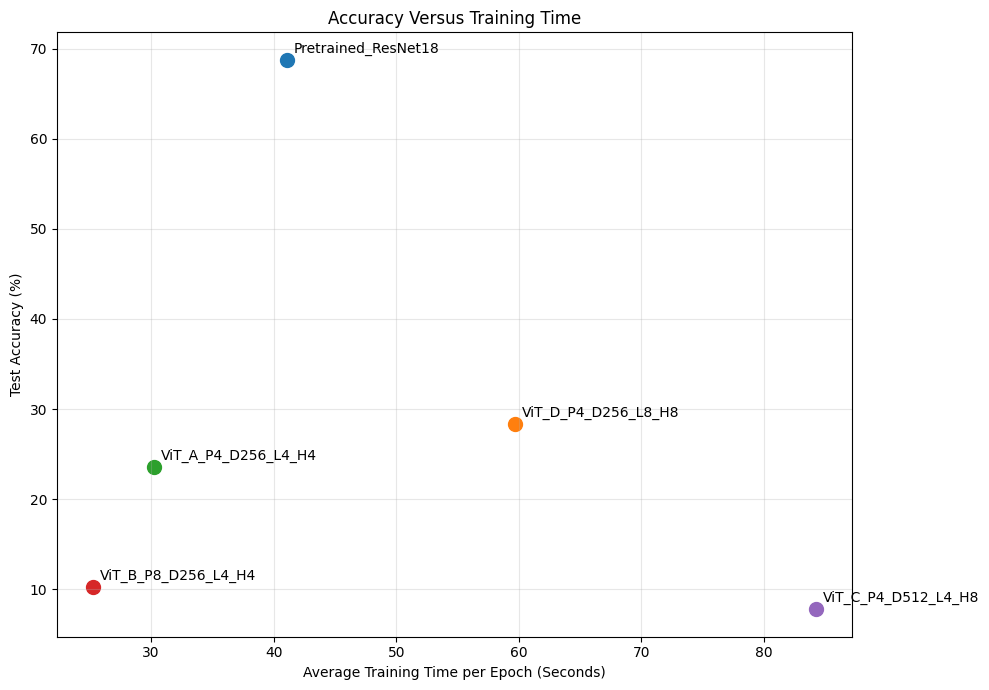

In [39]:
plt.figure(figsize=(10, 7))

for _, row in results_dataframe.iterrows():
    plt.scatter(
        row["Average Time per Epoch (s)"],
        row["Test Accuracy (%)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["Average Time per Epoch (s)"],
            row["Test Accuracy (%)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Training Time per Epoch (Seconds)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Versus Training Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/problem1_accuracy_vs_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
import glob
import zipfile

files_to_include = []

files_to_include.extend(
    glob.glob("/content/problem1_*.csv")
)

files_to_include.extend(
    glob.glob("/content/problem1_*.json")
)

files_to_include.extend(
    glob.glob("/content/problem1_*.png")
)

files_to_include.extend(
    glob.glob("/content/*_best.pth")
)

zip_path = "/content/HW5_Problem1_Outputs.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for file_path in files_to_include:
        zip_file.write(
            file_path,
            arcname=os.path.basename(file_path)
        )

print("ZIP file created:", zip_path)
print("Files included:")

for file_path in files_to_include:
    print("-", os.path.basename(file_path))

ZIP file created: /content/HW5_Problem1_Outputs.zip
Files included:
- problem1_final_results.csv
- problem1_all_histories.json
- problem1_validation_accuracy.png
- problem1_accuracy_vs_flops.png
- problem1_training_accuracy.png
- problem1_training_loss.png
- problem1_accuracy_vs_parameters.png
- problem1_validation_loss.png
- problem1_accuracy_vs_time.png
- problem1_test_accuracy.png
- ViT_C_P4_D512_L4_H8_best.pth
- ViT_B_P8_D256_L4_H4_best.pth
- Pretrained_ResNet18_best.pth
- ViT_D_P4_D256_L8_H8_best.pth
- ViT_A_P4_D256_L4_H4_best.pth


In [41]:
from google.colab import files

files.download(
    "/content/HW5_Problem1_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>